In [1]:
#!pip install seaborn

In [2]:
import pandas as pd

In [3]:
data = pd.read_csv('../../datasets/pima_indians_diabetes.csv')
data.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
X = data.iloc[:,:8]
y = data.iloc[:,8]

In [5]:
X.head()

,preg,plas,pres,skin,test,mass,pedi,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [6]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: class, dtype: int64

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train.shape,X_test.shape, y_train.shape, y_test.shape

((614, 8), (154, 8), (614,), (154,))

#### Build the model

In [9]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
model = SVC(C=1, gamma=0.001)
model.fit(X_train,y_train)

SVC(C=1, gamma=0.001)

              precision    recall  f1-score   support

           0       0.85      0.94      0.89       401
           1       0.86      0.69      0.77       213

    accuracy                           0.86       614
   macro avg       0.86      0.82      0.83       614
weighted avg       0.86      0.86      0.85       614



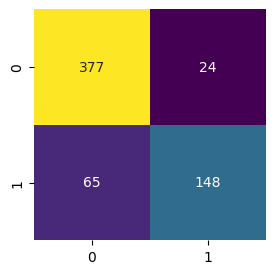

In [11]:
yhat_train = model.predict(X_train)
cm = confusion_matrix(y_train,yhat_train)
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, cmap='viridis', fmt='d', cbar=False)
print(classification_report(y_train,yhat_train))

              precision    recall  f1-score   support

           0       0.76      0.79      0.77        99
           1       0.59      0.55      0.57        55

    accuracy                           0.70       154
   macro avg       0.67      0.67      0.67       154
weighted avg       0.70      0.70      0.70       154



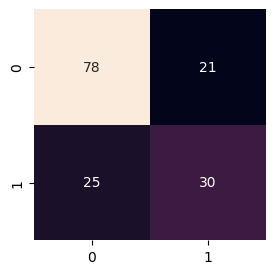

In [12]:
yhat_test = model.predict(X_test)
cm = confusion_matrix(y_test,yhat_test)
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, cmap='rocket', fmt='d', cbar=False)
print(classification_report(y_test,yhat_test))

##### Hyperparameter Tuning using Gridsearch

In [14]:
from sklearn.model_selection import GridSearchCV

In [15]:
pgrid = [
    {
        'C': [0.4,0.45,0.5,0.55,0.6],
        'gamma':[0.1,0.01,1]
    }
    
]

In [17]:
model = SVC()
grid = GridSearchCV(model,param_grid=pgrid, cv=10)
grid.fit(X_train,y_train)

GridSearchCV(cv=10, estimator=SVC(),
             param_grid=[{'C': [0.4, 0.45, 0.5, 0.55, 0.6],
                          'gamma': [0.1, 0.01, 1]}])

In [18]:
grid.best_params_

{'C': 0.6, 'gamma': 0.01}

In [19]:
final_model = grid.best_estimator_

              precision    recall  f1-score   support

           0       0.73      1.00      0.84       401
           1       0.98      0.31      0.47       213

    accuracy                           0.76       614
   macro avg       0.86      0.65      0.65       614
weighted avg       0.82      0.76      0.71       614



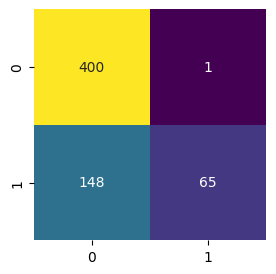

In [21]:
yhat_train = final_model.predict(X_train)
cm = confusion_matrix(y_train,yhat_train)
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, cmap='viridis', fmt='d', cbar=False)
print(classification_report(y_train,yhat_train))

              precision    recall  f1-score   support

           0       0.65      1.00      0.79        99
           1       1.00      0.02      0.04        55

    accuracy                           0.65       154
   macro avg       0.82      0.51      0.41       154
weighted avg       0.77      0.65      0.52       154



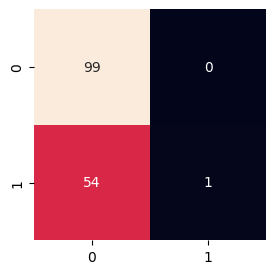

In [22]:
yhat_test = final_model.predict(X_test)
cm = confusion_matrix(y_test,yhat_test)
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, cmap='rocket', fmt='d', cbar=False)
print(classification_report(y_test,yhat_test))